In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import plotly.graph_objs as go
import plotly.figure_factory as ff
from plotly import tools
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
from sklearn.utils import resample

import gc
import time
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import roc_auc_score, recall_score
from sklearn.ensemble import RandomForestClassifier

In [3]:
# Path ke file data di drive setelah mount
file_path = 'bank-full.csv'  # Ganti dengan path file sesuai dengan struktur folder Anda

# Load data menggunakan pandas
databank = pd.read_csv(file_path)
df = databank


# Menampilkan beberapa baris pertama data
print("Isi Data:")
print(df.head())

Isi Data:
   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    1        1          1        2     2143        1     2        1   
1   44    2        2          2        2       29        1     2        1   
2   33    3        1          2        2        2        1     1        1   
3   47    4        1          3        2     1506        1     2        1   
4   33    5        2          3        2        1        2     2        1   

   day  month  duration  campaign  pdays  previous  poutcome  y  
0    5      5       261         1     -1         0         1  0  
1    5      5       151         1     -1         0         1  0  
2    5      5        76         1     -1         0         1  0  
3    5      5        92         1     -1         0         1  0  
4    5      5       198         1     -1         0         1  0  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  int64
 2   marital    45211 non-null  int64
 3   education  45211 non-null  int64
 4   default    45211 non-null  int64
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  int64
 7   loan       45211 non-null  int64
 8   contact    45211 non-null  int64
 9   day        45211 non-null  int64
 10  month      45211 non-null  int64
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  int64
 16  y          45211 non-null  int64
dtypes: int64(17)
memory usage: 5.9 MB


In [5]:
# Mengecek missing value dalam dataset
missing_values = df.isnull().sum()

# Menampilkan jumlah missing value untuk setiap kolom
print("Jumlah Missing Value untuk Setiap Kolom:")
print(missing_values)

# Jika ingin mengetahui total keseluruhan missing value dalam dataset, bisa menggunakan:
total_missing = missing_values.sum()
print("Total Missing Value dalam Dataset:", total_missing)

# Jika ingin menampilkan persentase missing value untuk setiap kolom:
percentage_missing = (missing_values / len(databank)) * 100
print("\nPersentase Missing Value untuk Setiap Kolom:")
print(percentage_missing)


Jumlah Missing Value untuk Setiap Kolom:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
Total Missing Value dalam Dataset: 0

Persentase Missing Value untuk Setiap Kolom:
age          0.0
job          0.0
marital      0.0
education    0.0
default      0.0
balance      0.0
housing      0.0
loan         0.0
contact      0.0
day          0.0
month        0.0
duration     0.0
campaign     0.0
pdays        0.0
previous     0.0
poutcome     0.0
y            0.0
dtype: float64


Distribusi Class:
0    39922
1     5289
Name: y, dtype: int64


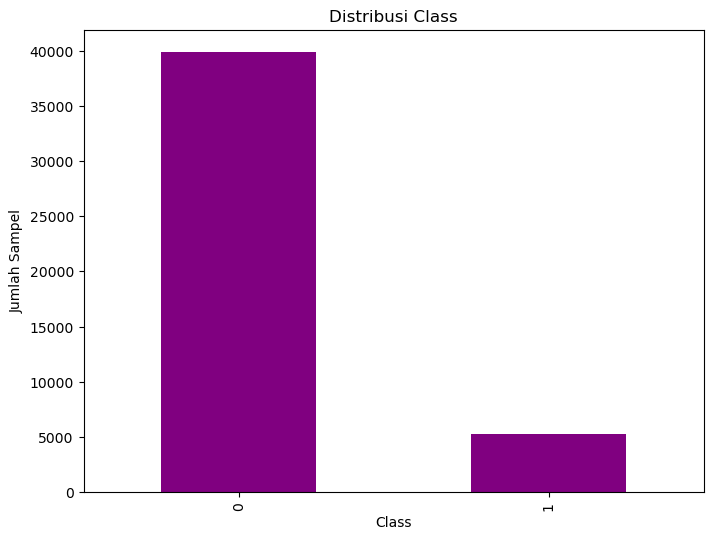

In [6]:
#cek distribusi kolom target
class_distribution = df['y'].value_counts()
print("Distribusi Class:")
print(class_distribution)

import matplotlib.pyplot as plt

# Visualisasi distribusi kelas
plt.figure(figsize=(8, 6))
class_distribution.plot(kind='bar', color='purple')
plt.title('Distribusi Class')
plt.xlabel('Class')
plt.ylabel('Jumlah Sampel')
plt.show()

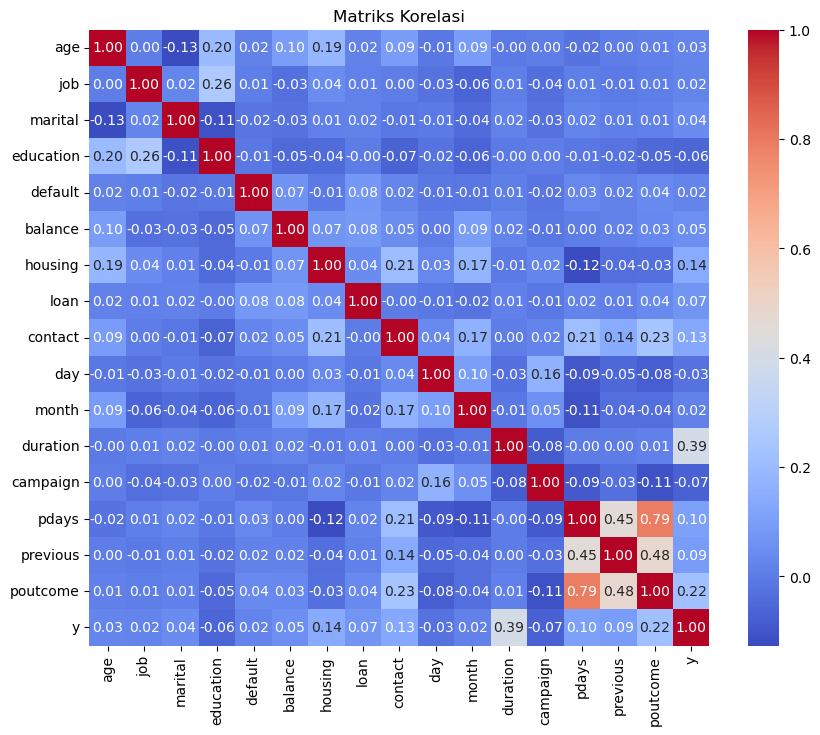

In [7]:
correlation_matrix = df.corr()

# Visualisasi matriks korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi')
plt.show()

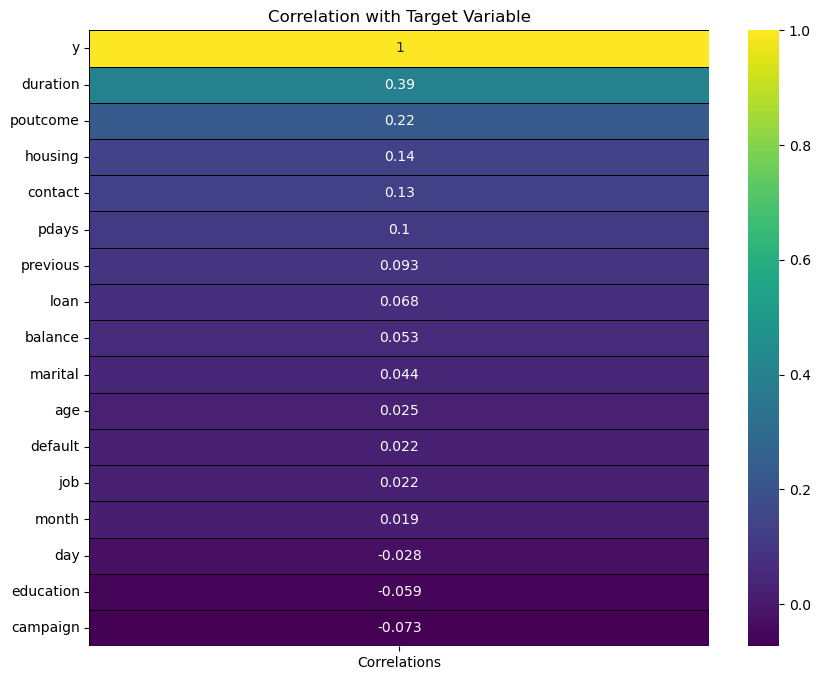

In [8]:
# Calculate the correlation of all features with the target variable 'y'
corr = df.corrwith(df['y']).sort_values(ascending=False).to_frame()
corr.columns = ['Correlations']

# Plotting the correlations using seaborn heatmap
plt.subplots(figsize=(10, 8))  # Adjust the figsize as needed
sns.heatmap(corr, annot=True, cmap='viridis', linewidths=0.4, linecolor='black')
plt.title('Correlation with Target Variable')
plt.show()

## Splitting Data

In [9]:
from sklearn.model_selection import train_test_split


X = df.drop(columns=['y'])
y = df['y']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature Selection

### Anova

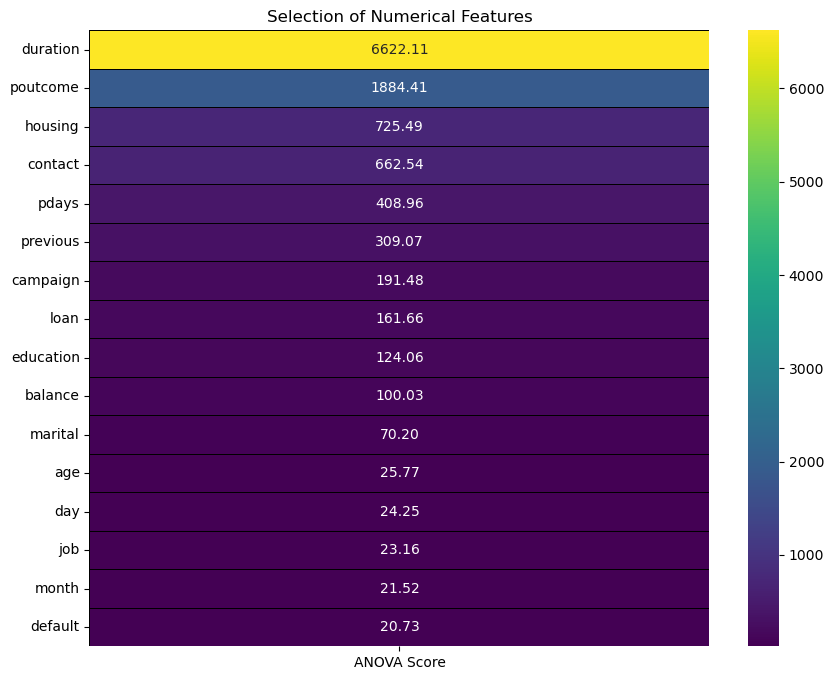

In [10]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif


best_features = SelectKBest(score_func = f_classif,k = 'all')
fit = best_features.fit(X_train,y_train)

# Create a DataFrame for the feature scores
feature_scores = pd.DataFrame(data=fit.scores_, index=X_train.columns, columns=['ANOVA Score'])

# Sort the feature scores in descending order
feature_scores = feature_scores.sort_values(by='ANOVA Score', ascending=False)

# Plotting the feature scores using seaborn heatmap
plt.subplots(figsize=(10, 8))  # Adjust the figsize as needed
sns.heatmap(feature_scores, annot=True, cmap='viridis', linewidths=0.4, linecolor='black', fmt='.2f')
plt.title('Selection of Numerical Features')
plt.show()

### Mutual Information

https://guhanesvar.medium.com/feature-selection-based-on-mutual-information-gain-for-classification-and-regression-d0f86ea5262a

Mutual Information Classification


In [11]:
from sklearn.feature_selection import mutual_info_classif
mutual_info = mutual_info_classif(X_train, y_train)
mutual_info

array([0.01321607, 0.00771882, 0.00553419, 0.00491139, 0.0065287 ,
       0.02010535, 0.01164298, 0.00651583, 0.01719828, 0.00772398,
       0.02695607, 0.07085329, 0.00565728, 0.02638236, 0.01237977,
       0.03330774])

In [12]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False)

duration     0.070853
poutcome     0.033308
month        0.026956
pdays        0.026382
balance      0.020105
contact      0.017198
age          0.013216
previous     0.012380
housing      0.011643
day          0.007724
job          0.007719
default      0.006529
loan         0.006516
campaign     0.005657
marital      0.005534
education    0.004911
dtype: float64

<AxesSubplot:>

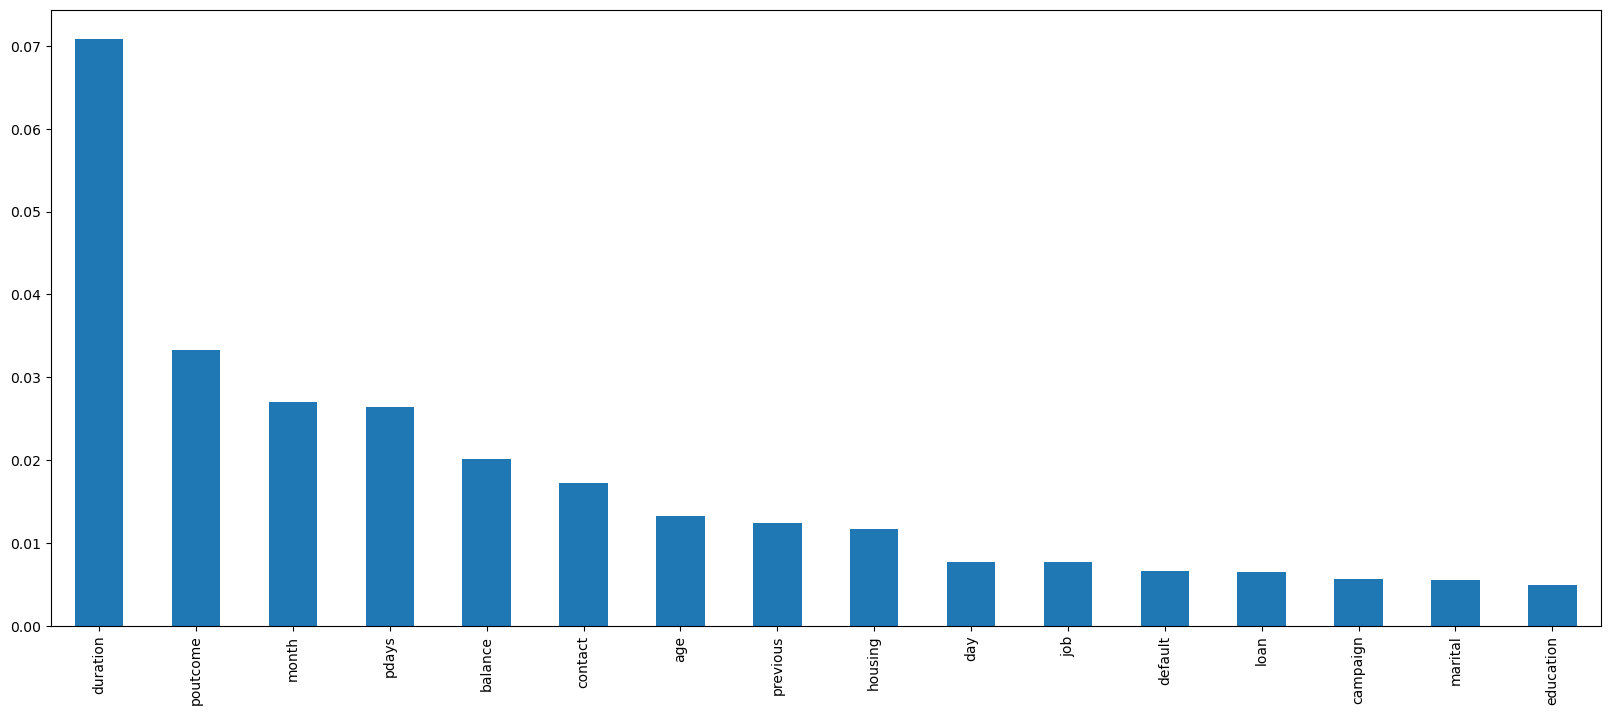

In [13]:
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20, 8))

In [14]:
from sklearn.feature_selection import SelectKBest
sel_five_cols = SelectKBest(mutual_info_classif, k=8)
sel_five_cols.fit(X_train, y_train)
X_train.columns[sel_five_cols.get_support()]

Index(['balance', 'housing', 'contact', 'month', 'duration', 'pdays',
       'previous', 'poutcome'],
      dtype='object')

Mutual Information Regression

In [15]:
from sklearn.feature_selection import mutual_info_regression
mutual_info_r = mutual_info_regression(X_train.fillna(0), y_train)
mutual_info_r

array([0.01059913, 0.00312274, 0.00910858, 0.00867431, 0.        ,
       0.01839955, 0.00739214, 0.00116803, 0.01854673, 0.00480513,
       0.0280951 , 0.07388953, 0.        , 0.01675971, 0.01848893,
       0.03346505])

In [16]:
mutual_info_r = pd.Series(mutual_info_r)
mutual_info_r.index = X_train.columns
mutual_info_r.sort_values(ascending=False)

duration     0.073890
poutcome     0.033465
month        0.028095
contact      0.018547
previous     0.018489
balance      0.018400
pdays        0.016760
age          0.010599
marital      0.009109
education    0.008674
housing      0.007392
day          0.004805
job          0.003123
loan         0.001168
default      0.000000
campaign     0.000000
dtype: float64

<AxesSubplot:>

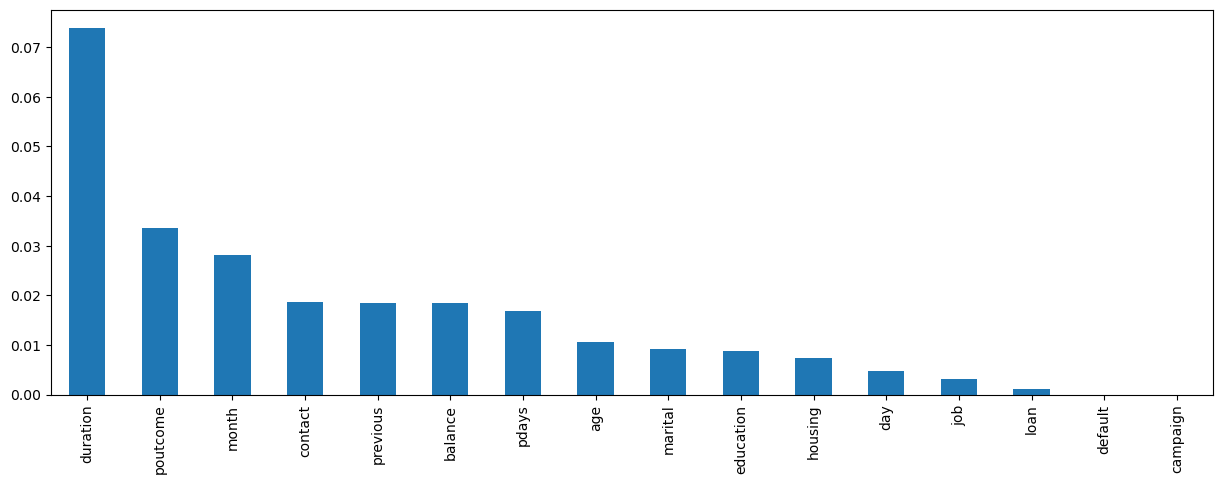

In [17]:
mutual_info_r.sort_values(ascending=False).plot.bar(figsize=(15,5))

In [18]:
from sklearn.feature_selection import SelectPercentile
selected_top_columns = SelectPercentile(mutual_info_regression, percentile=20)
selected_top_columns.fit(X_train.fillna(0), y_train)
selected_top_columns.get_support()

array([False, False, False, False, False, False, False, False, False,
       False, False,  True, False,  True, False,  True])

In [19]:
X_train.columns[selected_top_columns.get_support()]

Index(['duration', 'pdays', 'poutcome'], dtype='object')

# Sampling

In [22]:
# Calculate the count of 'yes' and 'no' in the 'y' column
yes_count = (df['y'] == 1).sum()
no_count = (df['y'] == 0).sum()

# Calculate the total count of values in the 'y' column
total_count = len(df)

# Calculate the percentage of 'yes' and 'no'
percentage_yes = (yes_count / total_count) * 100
percentage_no = (no_count / total_count) * 100
print("before sampling")
print("Percentage of 'yes'/1 in 'y':", percentage_yes)
print("Percentage of 'no'/0 in 'y':", percentage_no)

before sampling
Percentage of 'yes'/1 in 'y': 11.698480458295547
Percentage of 'no'/0 in 'y': 88.30151954170445


# Imbalance Data

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=123)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [24]:
# Concatenate the resampled 'X' and 'y' to form a new DataFrame
resampled_data = pd.concat([X_resampled, pd.Series(y_resampled, name='y')], axis=1)

After sampling
Percentage of 'yes' in 'y': 50.0
Percentage of 'no' in 'y': 50.0


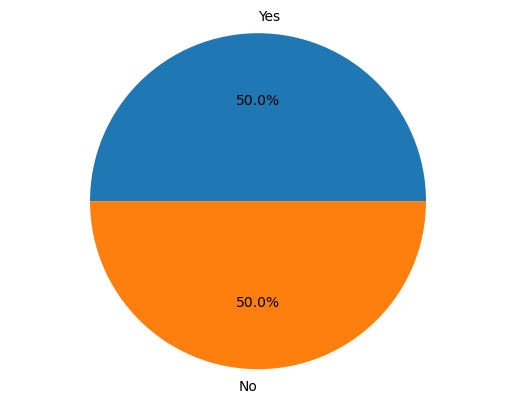

In [25]:
# Calculate the count of 'yes' and 'no' in the 'y' column
yes_count = (resampled_data['y'] == 1).sum()
no_count = (resampled_data['y'] == 0).sum()

# Calculate the total count of values in the 'y' column
total_count = len(resampled_data)

# Calculate the percentage of 'yes' and 'no'
percentage_yes = (yes_count / total_count) * 100
percentage_no = (no_count / total_count) * 100
print("After sampling")
print("Percentage of 'yes' in 'y':", percentage_yes)
print("Percentage of 'no' in 'y':", percentage_no)


# Create a pie chart
labels = ['Yes', 'No']
sizes = [percentage_yes, percentage_no]
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Splitting Resamled Data

In [26]:
# Separate features (X) and the target variable (y) from the resampled data
X_resampled = resampled_data.drop('y', axis=1)
y_resampled = resampled_data['y']

# Split the data into training and testing sets (e.g., 80% for training and 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Model

## Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression

# Initialize the model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

c:\Users\arbih\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

Accuracy: 0.7748137015467468

Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.76      0.79      0.78      7908
           1       0.79      0.76      0.77      8061

    accuracy                           0.77     15969
   macro avg       0.78      0.77      0.77     15969
weighted avg       0.78      0.77      0.77     15969


Confusion Matrix for Test Set:
[[6227 1681]
 [1915 6146]]


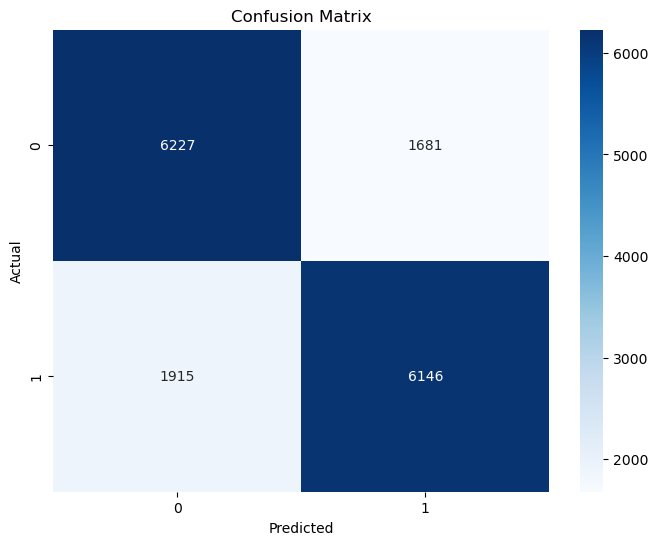

In [28]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Use other metrics as needed (e.g., precision, recall, F1-score)
# Generate a classification report for the test set
print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_pred))

# Generate a confusion matrix for the test set
print("\nConfusion Matrix for Test Set:")
print(confusion_matrix(y_test, y_pred))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [30]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [31]:
y_pred = clf.predict(X_test)

### Evaluate Performance Model

Training Accuracy: 1.0

Test Accuracy: 0.9234767361763416

Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      7908
           1       0.90      0.95      0.93      8061

    accuracy                           0.92     15969
   macro avg       0.93      0.92      0.92     15969
weighted avg       0.92      0.92      0.92     15969


Confusion Matrix for Test Set:
[[7058  850]
 [ 372 7689]]


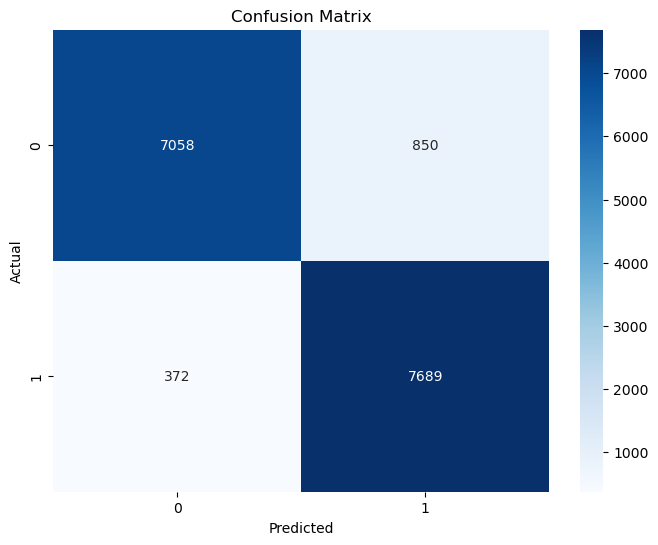

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the training data
y_train_pred = clf.predict(X_train)

# Calculate and print accuracy for the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", train_accuracy)

# Make predictions on the test data
y_test_pred = clf.predict(X_test)

# Calculate and print accuracy for the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
print("\nTest Accuracy:", test_accuracy)

# Generate a classification report for the test set
print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_test_pred))

# Generate a confusion matrix for the test set
print("\nConfusion Matrix for Test Set:")
print(confusion_matrix(y_test, y_test_pred))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Feature Importance

In [33]:
feature_importance = clf.feature_importances_
# You can associate these scores with feature names for better understanding
feature_names = X_train.columns
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance (descending order)
sorted_feature_importance = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)
for feature, importance in sorted_feature_importance:
    print(f"{feature}: {importance:.4f}")

duration: 0.3555
month: 0.1060
balance: 0.0805
day: 0.0754
age: 0.0649
pdays: 0.0585
education: 0.0565
job: 0.0444
campaign: 0.0379
contact: 0.0313
poutcome: 0.0225
marital: 0.0216
previous: 0.0184
housing: 0.0171
loan: 0.0080
default: 0.0016


### Hyperparameter Tuning

In [34]:
clf2 = RandomForestClassifier(n_estimators= 200, max_depth =20,min_samples_leaf= 1,min_samples_split=2, random_state=42)

# Train the model
clf2.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42)

In [35]:
y_pred = clf2.predict(X_test)

Training Accuracy: 0.9879608610567515

Test Accuracy: 0.9206587763792348

Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      7908
           1       0.90      0.95      0.92      8061

    accuracy                           0.92     15969
   macro avg       0.92      0.92      0.92     15969
weighted avg       0.92      0.92      0.92     15969


Confusion Matrix for Test Set:
[[7016  892]
 [ 375 7686]]


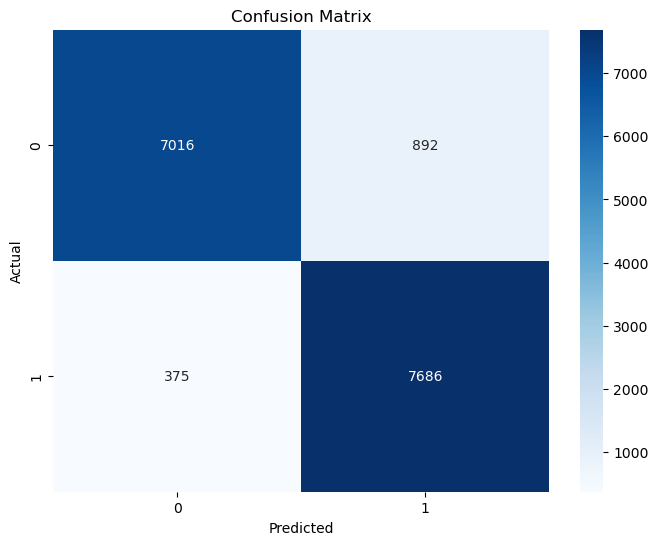

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the training data
y_train_pred = clf2.predict(X_train)

# Calculate and print accuracy for the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", train_accuracy)

# Make predictions on the test data
y_test_pred = clf2.predict(X_test)

# Calculate and print accuracy for the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
print("\nTest Accuracy:", test_accuracy)

# Generate a classification report for the test set
print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_test_pred))

# Generate a confusion matrix for the test set
print("\nConfusion Matrix for Test Set:")
print(confusion_matrix(y_test, y_test_pred))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Decision Tree

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [38]:
clf3 = DecisionTreeClassifier(random_state=42)

# Train the model
clf3.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [39]:
y_pred = clf3.predict(X_test)

Training Accuracy: 1.0

Test Accuracy: 0.8840879203456697

Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      7908
           1       0.88      0.90      0.89      8061

    accuracy                           0.88     15969
   macro avg       0.88      0.88      0.88     15969
weighted avg       0.88      0.88      0.88     15969


Confusion Matrix for Test Set:
[[6877 1031]
 [ 820 7241]]


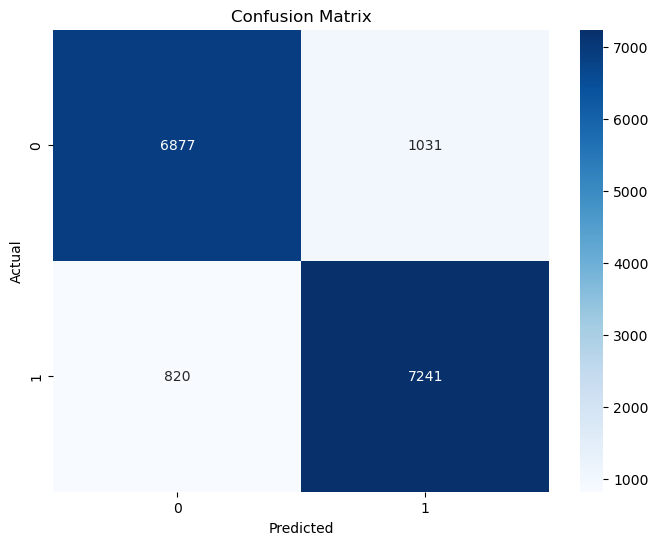

In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the training data
y_train_pred = clf3.predict(X_train)

# Calculate and print accuracy for the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", train_accuracy)

# Make predictions on the test data
y_test_pred = clf3.predict(X_test)

# Calculate and print accuracy for the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
print("\nTest Accuracy:", test_accuracy)

# Generate a classification report for the test set
print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_test_pred))

# Generate a confusion matrix for the test set
print("\nConfusion Matrix for Test Set:")
print(confusion_matrix(y_test, y_test_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Parameter Tuning

In [41]:
clf4 = DecisionTreeClassifier(random_state=42 , criterion='gini', max_depth=20 ,min_samples_split= 2)

# Train the model
clf4.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=20, random_state=42)

In [42]:
y_pred = clf4.predict(X_test)

Training Accuracy: 0.983279843444227

Test Accuracy: 0.8853403469221617

Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      7908
           1       0.87      0.91      0.89      8061

    accuracy                           0.89     15969
   macro avg       0.89      0.89      0.89     15969
weighted avg       0.89      0.89      0.89     15969


Confusion Matrix for Test Set:
[[6834 1074]
 [ 757 7304]]


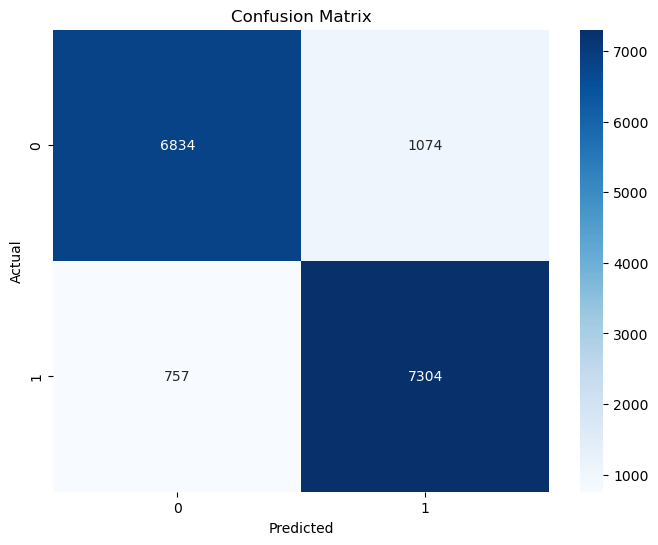

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the training data
y_train_pred = clf4.predict(X_train)

# Calculate and print accuracy for the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", train_accuracy)

# Make predictions on the test data
y_test_pred = clf4.predict(X_test)

# Calculate and print accuracy for the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
print("\nTest Accuracy:", test_accuracy)

# Generate a classification report for the test set
print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_test_pred))

# Generate a confusion matrix for the test set
print("\nConfusion Matrix for Test Set:")
print(confusion_matrix(y_test, y_test_pred))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()